# Fractal Analysis of Wild Boar Telemetry Data

In [12]:
# Load required libraries
library(pacman)
p_load(dplyr,
      trajr,
      sf,
      lubridate)


In [13]:
# Load the raw telemetry CSV
boar_raw <- read.csv("../data/raw/WS_Masterfile_final_with_cultures_Aargau.csv", sep = ";")

# Convert to a spatial object using the raw GPS coordinates (WGS84 / EPSG:4326)
boar_sf_4326 <- st_as_sf(boar_raw, 
                         coords = c("Long", "Lat"), 
                         crs = 4326) 

# Project to the modern Swiss coordinate system (LV95 / EPSG:2056)
boar_sf_lv95 <- st_transform(boar_sf_4326, 2056)

# Extract the newly calculated Swiss metric coordinates back into a clean data frame
coords <- st_coordinates(boar_sf_lv95)
boar_df <- st_drop_geometry(boar_sf_lv95)
boar_df$X_LV95 <- coords[, "X"]
boar_df$Y_LV95 <- coords[, "Y"]

# Convert the text timestamp into a true mathematical Datetime object
boar_df$ZeitpUTC <- dmy_hm(boar_df$ZeitpUTC, tz = "UTC")

# Sort the data chronologically by Animal ID and Time
# Trajectory analysis will fail if the GPS points are out of order!
boar_df <- boar_df %>% 
  arrange(Tier, ZeitpUTC)

[1] "Generating trajectory plot for sanity check..."


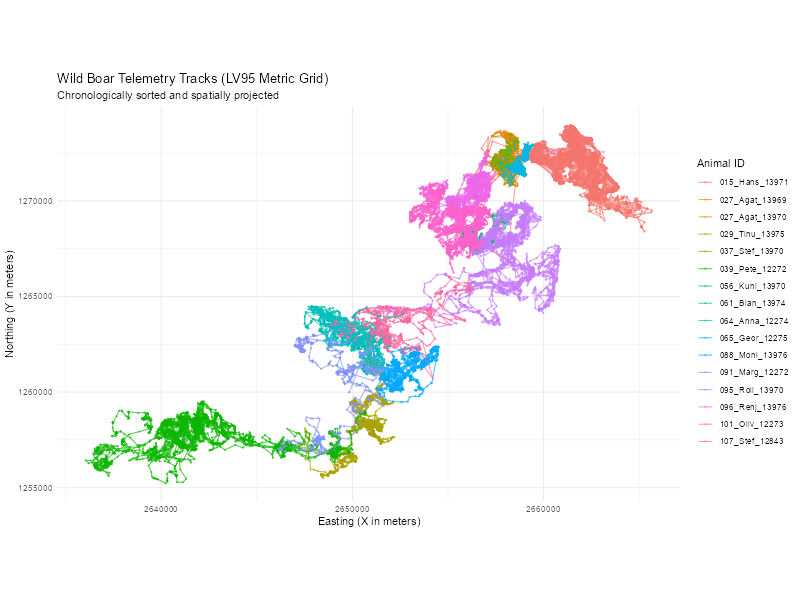

In [14]:
# Load ggplot2 for visualization
library(ggplot2)

print("Generating trajectory plot for sanity check...")

# Create a map of the wild boar tracks
ggplot(data = boar_df, aes(x = X_LV95, y = Y_LV95, color = as.factor(Tier))) +
  # Draw the paths connecting the chronological points
  geom_path(alpha = 0.7, linewidth = 0.5) +
  # Add the actual GPS points as tiny dots
  geom_point(size = 0.5, alpha = 0.5) +
  # Force the aspect ratio to be exactly 1:1 so the map isn't stretched
  coord_equal() +
  # Aesthetic formatting
  theme_minimal() +
  labs(
    title = "Wild Boar Telemetry Tracks (LV95 Metric Grid)",
    subtitle = "Chronologically sorted and spatially projected",
    x = "Easting (X in meters)",
    y = "Northing (Y in meters)",
    color = "Animal ID"
  ) +
  theme(legend.position = "right")

[1] "Calculating Autocorrelation for the real wild boar path..."
[1] "Generating CRW and calculating its Autocorrelation..."


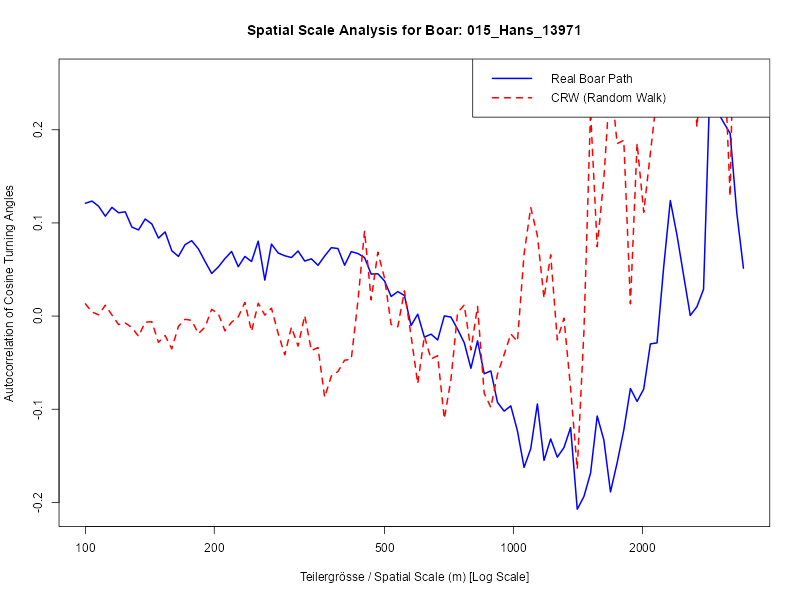

In [15]:
# Path Discretization and CRW Comparison (Nams 2004 Method)

# Isolate a single animal to calculate the threshold scale
boar_id <- unique(boar_df$Tier)[1]
boar_single <- boar_df %>% filter(Tier == boar_id)

# Create the Trajectory Object
trj <- TrajFromCoords(boar_single, xCol = "X_LV95", yCol = "Y_LV95", timeCol = "ZeitpUTC")

# Find the maximum distance between any two points in the track
max_dist <- max(dist(cbind(boar_single$X_LV95, boar_single$Y_LV95)))
max_divider <- max_dist / 3

# Create 100 divider lengths geometrically
dividers <- exp(seq(log(100), log(max_divider), length.out = 100))

# Create a function to calculate Autocorrelation of Cosine Turning Angles
calc_autocorr <- function(path, step_sizes) {
  acf_vals <- numeric(length(step_sizes))
  
  for(i in seq_along(step_sizes)) {
    # Rediscretize the path
    redis <- TrajRediscretize(path, step_sizes[i])
    
    # Ensure the path is still long enough to have angles
    if(nrow(redis) > 3) {
      # Calculate Cosine of Angles
      angles <- TrajAngles(redis)
      cos_angles <- cos(angles[!is.na(angles)])
      
      # Lag-1 Autocorrelation
      if(length(cos_angles) > 3) {
        acf_vals[i] <- acf(cos_angles, lag.max = 1, plot = FALSE)$acf[2]
      } else { acf_vals[i] <- NA }
    } else { acf_vals[i] <- NA }
  }
  return(acf_vals)
}

# Calculate the Autocorrelation for the REAL Wild Boar
print("Calculating Autocorrelation for the real wild boar path...")
real_acf <- calc_autocorr(trj, dividers)

# Calculate observed mean step length and angular standard deviation
obs_sl <- TrajStepLengths(trj)
mean_sl <- mean(obs_sl, na.rm = TRUE)
sd_angle <- sd(TrajAngles(trj), na.rm = TRUE)

# Generate the CRW with identical number of GPS fixes
print("Generating CRW and calculating its Autocorrelation...")
crw <- TrajGenerate(n = nrow(boar_single), 
                    stepLength = mean_sl, 
                    angularErrorSd = sd_angle)

# Calculate Autocorrelation for the CRW
crw_acf <- calc_autocorr(crw, dividers)


# Plot the Results to Find the Threshold Scale
# We plot Divider Size (x-axis) vs Autocorrelation (y-axis) on a logarithmic scale
plot(dividers, real_acf, type = "l", col = "blue", lwd = 2, log = "x",
     xlab = "Teilergrösse / Spatial Scale (m) [Log Scale]", 
     ylab = "Autocorrelation of Cosine Turning Angles",
     main = paste("Spatial Scale Analysis for Boar:", boar_id))

# Add the CRW (Null Model) for comparison
lines(dividers, crw_acf, col = "red", lwd = 2, lty = 2)

legend("topright", legend = c("Real Boar Path", "CRW (Random Walk)"),
       col = c("blue", "red"), lwd = 2, lty = c(1, 2))

In [16]:
p_load(mclust,
      foreach,
      doParallel,
      amt)

# ------------------------------------------------------------------------------
# STEP 2: The Core Loop - Process Every Animal Individually
# ------------------------------------------------------------------------------

# Create an empty list to store the classified data for each animal
classified_animals <- list()
animal_ids <- unique(boar_df$Tier)
n_simulations <- 50 # Set to 50 for testing, 100 for final thesis run

# Setup Parallel Processing to make simulations lightning fast
no_cores <- detectCores() - 1  
cl <- makeCluster(no_cores)
registerDoParallel(cl)

# Function to calculate autocorrelation of turning angles
calc_autocorr <- function(path, step_sizes) {
  acf_vals <- numeric(length(step_sizes))
  
  for(i in seq_along(step_sizes)) {
    
    # tryCatch prevents the crash if the ruler is too big
    redis <- tryCatch({
      TrajRediscretize(path, step_sizes[i])
    }, error = function(e) { NULL })
    
    # Only proceed if rediscretization worked AND the path has enough points to form angles
    if(!is.null(redis) && nrow(redis) > 3) {
      angles <- TrajAngles(redis)
      cos_angles <- cos(angles[!is.na(angles)])
      
      if(length(cos_angles) > 3) {
        
        # tryCatch around the autocorrelation math
        acf_res <- tryCatch({
          acf(cos_angles, lag.max = 1, plot = FALSE)$acf[2]
        }, error = function(e) { NA })
        
        acf_vals[i] <- acf_res
        
      } else { 
        acf_vals[i] <- NA 
      }
    } else { 
      acf_vals[i] <- NA 
    }
  }
  return(acf_vals)
}

print(paste("Starting behavioral classification for", length(animal_ids), "animals..."))

for(current_id in animal_ids) {
  print(paste("Processing Animal:", current_id))
  
  # 2a. Isolate the single animal
  boar_single <- boar_df %>% filter(Tier == current_id)
  trj <- TrajFromCoords(boar_single, xCol = "X_LV95", yCol = "Y_LV95", timeCol = "ZeitpUTC")
  
  # 2b. Generate geometric dividers (100m up to 1/3 of max distance)
  max_dist <- max(dist(cbind(boar_single$X_LV95, boar_single$Y_LV95)))
  max_divider <- max_dist / 3
  dividers <- exp(seq(log(100), log(max_divider), length.out = 50))
  
  # 2c. Calculate Autocorrelation for the REAL wild boar
  real_acf <- calc_autocorr(trj, dividers)
  
  # 2d. PARALLEL: Generate CRWs (Fake Boars) and calculate their autocorrelation
  mean_sl <- mean(TrajStepLengths(trj), na.rm = TRUE)
  sd_angle <- sd(TrajAngles(trj), na.rm = TRUE)
  
  crw_acf_matrix <- foreach(sim = 1:n_simulations, .combine = rbind, .packages = c("trajr")) %dopar% {
    crw <- TrajGenerate(n = nrow(boar_single), stepLength = mean_sl, angularErrorSd = sd_angle)
    calc_autocorr(crw, dividers)
  }
  
  # 2e. Calculate Z-Scores
  crw_mean <- colMeans(crw_acf_matrix, na.rm = TRUE)
  crw_sd   <- apply(crw_acf_matrix, 2, sd, na.rm = TRUE)
  z_scores <- (real_acf - crw_mean) / crw_sd
  
  # 2f. Find Optimal Spatial Scale (Top 10% Z-Score Dezil)
  z_threshold <- quantile(z_scores, 0.90, na.rm = TRUE)
  best_dividers <- dividers[z_scores >= z_threshold & !is.na(z_scores)]
  
  # If the animal doesn't show two behaviors (no valid Z-scores), skip or label all as In-Patch
  if(length(best_dividers) == 0) {
    boar_single$Final_Behavior <- "In-Patch"
    classified_animals[[as.character(current_id)]] <- boar_single
    next
  }
  
  optimal_scale <- best_dividers[which.max(z_scores[dividers %in% best_dividers])]
  
  # 2g. K-Means Clustering on the optimal scale
  redis_opt <- TrajRediscretize(trj, optimal_scale)
  angles <- abs(TrajAngles(redis_opt))
  angles <- ifelse(is.na(angles), 0, angles)
  
  kmeans_res <- kmeans(angles, centers = 2)
  patch_cluster <- which.max(kmeans_res$centers) # Larger angles = In-Patch
  
  # 2h. Net Squared Displacement (NSD) for every GPS point
  start_x <- boar_single$X_LV95[1]
  start_y <- boar_single$Y_LV95[1]
  boar_single$NSD <- (boar_single$X_LV95 - start_x)^2 + (boar_single$Y_LV95 - start_y)^2
  boar_single$log_NSD <- log(boar_single$NSD + 1)
  
  # 2i. GMM Refinement (Mclust)
  gmm_model <- Mclust(boar_single$log_NSD, G = 2)
  boar_single$GMM_Class <- gmm_model$classification
  gmm_matrix_class <- which.max(gmm_model$parameters$mean) # Higher NSD = In-Matrix
  
  boar_single$Final_Behavior <- ifelse(boar_single$GMM_Class == gmm_matrix_class, "In-Matrix", "In-Patch")
  
  # Store the classified animal
  classified_animals[[as.character(current_id)]] <- boar_single
}

# Stop the parallel cluster
stopCluster(cl)

# Combine all animals back into one massive dataset
all_classified_boars <- bind_rows(classified_animals)
print("All animals successfully classified!")



[1] "Starting behavioral classification for 16 animals..."
[1] "Processing Animal: 015_Hans_13971"
fitting ...
  |======================================================================================================| 100%
[1] "Processing Animal: 027_Agat_13969"
fitting ...
  |======================================================================================================| 100%
[1] "Processing Animal: 027_Agat_13970"
fitting ...
  |======================================================================================================| 100%
[1] "Processing Animal: 029_Tinu_13975"
fitting ...
  |======================================================================================================| 100%
[1] "Processing Animal: 037_Stef_13970"
fitting ...
  |======================================================================================================| 100%
[1] "Processing Animal: 039_Pete_12272"
fitting ...
  |==================================================================

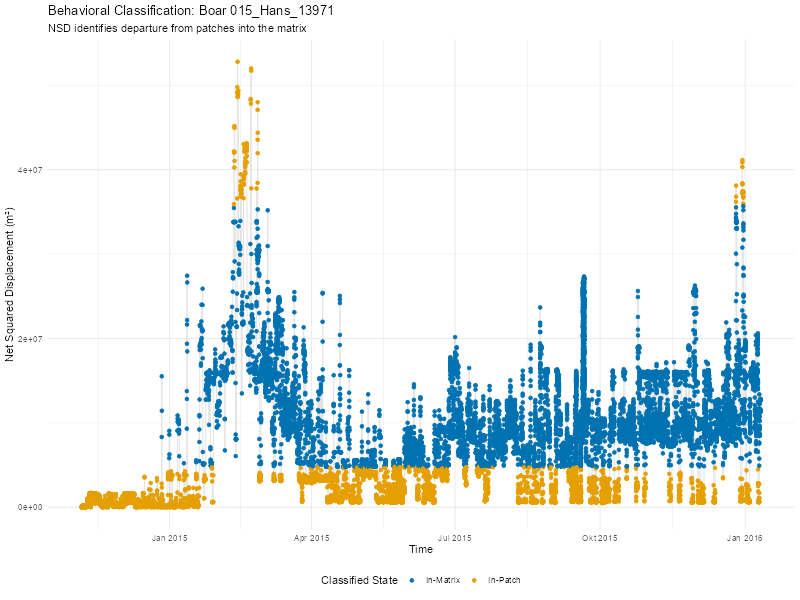

In [17]:
library(ggplot2)

# Choose one boar to show the result clearly
example_boar <- all_classified_boars %>% filter(Tier == animal_ids[1])

ggplot(example_boar, aes(x = ZeitpUTC, y = NSD, color = Final_Behavior)) +
  geom_line(aes(group = 1), color = "gray80", alpha = 0.5) +
  geom_point(size = 1.5) +
  scale_color_manual(values = c("In-Patch" = "#E69F00", "In-Matrix" = "#0072B2")) +
  theme_minimal() +
  labs(
    title = paste("Behavioral Classification: Boar", animal_ids[1]),
    subtitle = "NSD identifies departure from patches into the matrix",
    x = "Time",
    y = "Net Squared Displacement (m²)",
    color = "Classified State"
  ) +
  theme(legend.position = "bottom")

In [18]:
print("1. Filtering for the specific boar and preparing spatial data...")

# Identify the boar ID you want (using the same one from your previous Nams code)
# Or manually set: target_id <- "015_Hans_13971"
target_id <- boar_id 

# Filter the classified data
single_boar_data <- all_classified_boars %>% 
  filter(Tier == target_id)

# Create spatial object for the bounding box
single_boar_sf <- st_as_sf(single_boar_data, coords = c("X_LV95", "Y_LV95"), crs = 2056)

print("2. Downloading background tiles for the specific home range...")
# Zoom 13 or 14 is often better for a single animal to see field-level detail
bg_map_single <- get_tiles(single_boar_sf, provider = "CartoDB.Positron", zoom = 13, crop = TRUE)

print("3. Generating final plot for the single boar...")

ggplot() +
  # --- Layer 1: Basemap ---
  geom_spatraster_rgb(data = bg_map_single, maxcell = 1e6) +
  
  # --- Layer 2: Behavioral Paths ---
  geom_path(data = single_boar_data, 
            aes(x = X_LV95, y = Y_LV95, color = Final_Behavior), 
            alpha = 0.9, linewidth = 1) +
  
  # --- Layer 3: Individual Fixes ---
  geom_point(data = single_boar_data, 
             aes(x = X_LV95, y = Y_LV95, color = Final_Behavior), 
             size = 0.8, alpha = 0.7) +
  
  # Spatial Settings
  coord_sf(crs = 2056) +
  scale_color_manual(values = c("In-Patch" = "#E69F00", "In-Matrix" = "#0072B2")) +
  
  theme_minimal() +
  labs(
    title = paste("Movement Ecology of Boar:", target_id),
    subtitle = "In-Patch (Resting/Foraging) vs. In-Matrix (Migration/Transit)",
    x = "Easting (LV95)",
    y = "Northing (LV95)",
    color = "Behavior"
  ) +
  theme(legend.position = "bottom",
        plot.title = element_text(face = "bold", size = 14))

print("Single boar plot successfully generated!")

[1] "1. Filtering for the specific boar and preparing spatial data..."
[1] "2. Downloading background tiles for the specific home range..."


: [1m[33mError[39m:[22m
[33m![39m could not find function "get_tiles"

In [ ]:
p_load(zoo) # Required for the smoothing filter

library(zoo)

classified_animals <- list()
animal_ids <- unique(boar_df$Tier)

print("Starting Voting Logic with corrected column names...")

for(current_id in animal_ids) {
  
  # 1. Isolate animal and calculate turning angles
  boar_single <- boar_df %>% filter(Tier == current_id) %>% arrange(ZeitpUTC)
  
  # Create trajectory and get angles
  trj <- TrajFromCoords(boar_single, xCol = "X_LV95", yCol = "Y_LV95", timeCol = "ZeitpUTC")
  angles <- TrajAngles(trj)
  
  # Padding: TrajAngles returns n-2, so we add NA at start and end
  padded_angles <- c(NA, angles, NA)
  boar_single$straightness <- cos(abs(padded_angles)) 
  boar_single$straightness[is.na(boar_single$straightness)] <- 0
  
  # 2. THE VOTING MECHANISM
  # Using your exact column names: 'speed' and 'distance'
  boar_single <- boar_single %>%
    mutate(
      # We convert to numeric to ensure logical comparisons work
      speed_val = as.numeric(speed),
      dist_val  = as.numeric(distance)
    ) %>%
    mutate(
      # Thresholds (adjust if your units are not meters/hours)
      vote_speed    = ifelse(speed_val > 150, 1, 0),      
      vote_dist     = ifelse(dist_val > 100, 1, 0),       
      vote_straight = ifelse(straightness > 0.5, 1, 0)
    ) %>%
    mutate(
      total_votes = vote_speed + vote_dist + vote_straight,
      # Rule: 2 out of 3 criteria must be met
      Raw_Behavior = ifelse(total_votes >= 2, "In-Matrix", "In-Patch")
    )
  
# 3. THE BIOLOGICAL SMOOTHING (The "Glue")
  # We only smooth if we have at least 5 points to avoid interpolation errors
  if(nrow(boar_single) >= 5) {
    
    # We use a simple majority rule in a rolling window
    # 'align = center' and 'fill = NA' prevents the approx() error
    smoothed <- rollapply(boar_single$Raw_Behavior, width = 3, 
                          FUN = function(x) {
                            # Majority vote: which label appears most in the 3 points?
                            names(which.max(table(x)))
                          }, 
                          fill = NA, align = "center")
    
    # Fill the NAs created at the start/end by the window with the original Raw values
    boar_single$Final_Behavior <- ifelse(is.na(smoothed), boar_single$Raw_Behavior, smoothed)
    
  } else {
    # If the track is too short, just keep the raw classification
    boar_single$Final_Behavior <- boar_single$Raw_Behavior
  }

  # 4. NSD Calculation (Standard for movement analysis)
  start_x <- boar_single$X_LV95[1]
  start_y <- boar_single$Y_LV95[1]
  boar_single$NSD <- (boar_single$X_LV95 - start_x)^2 + (boar_single$Y_LV95 - start_y)^2

  classified_animals[[as.character(current_id)]] <- boar_single
}

all_classified_boars <- bind_rows(classified_animals)
print("Classification complete!")

[1] "Starting Voting Logic with corrected column names..."
[1] "Classification complete!"


In [ ]:
# p_load(
#   shiny,
#   bslib,
#   leaflet,
#   dplyr,
#   lubridate,
#   ggplot2,
#   sf,
#   bsicons
# )

# library(shiny)
# library(bslib)
# library(leaflet)
# library(dplyr)
# library(lubridate)
# library(ggplot2)
# library(sf)
# library(bsicons)

# # ==============================================================================
# # 1. PREPROCESS THE DATA
# # ==============================================================================
# # Ensure all_classified_boars is in your environment before running this!
# boar_processed <- all_classified_boars %>%
#   # Flexible parsing for different date-time formats
#   mutate(timestamp = parse_date_time(ZeitpUTC, orders = c("ymd HMS", "dmy HMS", "ymd HM"))) %>%
#   filter(!is.na(timestamp)) %>%
#   filter(!is.na(X_LV95) & !is.na(Y_LV95)) %>%
#   arrange(Tier, timestamp)

# # Transform LV95 (meters) to WGS84 (Lat/Long) for Leaflet
# boar_sf <- st_as_sf(boar_processed, coords = c("X_LV95", "Y_LV95"), crs = 2056) %>%
#   st_transform(4326)

# # Extract coordinates for use in the app
# coords <- st_coordinates(boar_sf)
# boar_processed$long <- coords[,1]
# boar_processed$lat <- coords[,2]

# unique_boars <- unique(boar_processed$Tier)

# # Define behavioral color palette
# behavior_pal <- colorFactor(
#   palette = c("#E69F00", "#0072B2"), # Orange = Patch, Blue = Matrix
#   levels = c("In-Patch", "In-Matrix")
# )

# # ==============================================================================
# # 2. UI: THE DASHBOARD LAYOUT
# # ==============================================================================
# ui <- page_navbar(
#   title = "Wild Boar: Aargau Connectivity Tracker",
#   theme = bs_theme(version = 5, bootswatch = "flatly"),
#   fillable = TRUE,
  
#   sidebar = sidebar(
#     width = 350,
#     h4("Movement Controls"),
#     hr(),
#     selectInput("boar_selector", "Select Individual Boar:", choices = unique_boars),
#     hr(),
#     radioButtons("playback_speed", "Animation Speed:", 
#                  choices = c("Slow" = 1000, "Med" = 400, "Fast" = 100), 
#                  selected = 400, inline = TRUE),
#     uiOutput("time_slider_ui"),
#     hr(),
#     h5("Visual Options"),
#     checkboxInput("show_lines", "Show Historical Path (Trails)", value = TRUE),
#     hr(),
#     p(em("Logic: Based on Fischer et al. (2024) HEPIA/ZHAW Methodology")),
#     # FIXED: Changed small(...) to tags$small(...)
#     p(tags$small("Orange: In-Patch | Blue: In-Matrix"))
#   ),
  
#   nav_panel(title = "Interactive Map", 
#             leafletOutput("map", width = "100%", height = "100%")
#   ),
  
#   nav_panel(title = "Behavioral Statistics",
#             layout_columns(
#               value_box(title = "Current State", 
#                         value = textOutput("stat_state"), 
#                         showcase = bs_icon("activity")),
#               value_box(title = "Max Range from Origin", 
#                         value = textOutput("stat_dist"), 
#                         showcase = bs_icon("rulers")),
#               value_box(title = "Total Fixes", 
#                         value = textOutput("stat_fixes"), 
#                         showcase = bs_icon("geo-alt"))
#             ),
            
#             navset_card_underline(
#               title = "Movement Profiles",
#               nav_panel("Displacement (NSD) over Time", 
#                         plotOutput("nsd_plot", height = "450px")
#               ),
#               nav_panel("Behavioral Time Budget", 
#                         plotOutput("behavior_pie", height = "450px")
#               )
#             )
#   )
# )

# # ==============================================================================
# # 3. SERVER: DYNAMIC MAP & BEHAVIOR LOGIC
# # ==============================================================================
# server <- function(input, output, session) {
  
#   # --- 1. REACTIVE DATA ---
#   selected_boar_data <- reactive({
#     req(input$boar_selector)
#     boar_processed %>% filter(Tier == input$boar_selector)
#   })
  
#   current_pos <- reactive({
#     req(selected_boar_data(), input$time_slider)
#     selected_boar_data() %>% 
#       filter(timestamp <= input$time_slider) %>%
#       slice_tail(n = 1)
#   })

#   # --- 2. DYNAMIC SLIDER ---
#   output$time_slider_ui <- renderUI({
#     data <- selected_boar_data()
#     req(data, nrow(data) > 0)
    
#     min_t <- min(data$timestamp, na.rm = TRUE)
#     max_t <- max(data$timestamp, na.rm = TRUE)
    
#     sliderInput("time_slider", "Timeline (Date & Time):", 
#                 min = min_t, max = max_t, value = min_t, 
#                 timeFormat = "%m-%d %H:%M", step = 3600, 
#                 animate = animationOptions(interval = as.numeric(input$playback_speed), loop = FALSE))
#   })
  
#   # --- 3. MAP RENDERING ---
#   output$map <- renderLeaflet({
#     leaflet() %>%
#       addProviderTiles(providers$CartoDB.Positron) %>%
#       addLegend(position = "bottomright", pal = behavior_pal, 
#                 values = c("In-Patch", "In-Matrix"), title = "Behavioral State")
#   })
  
#   observe({
#     req(current_pos(), selected_boar_data(), input$time_slider)
#     pos <- current_pos()
#     hist_path <- selected_boar_data() %>% filter(timestamp <= input$time_slider)
    
#     proxy <- leafletProxy("map") %>%
#       clearGroup("boar_marker") %>%
#       clearGroup("boar_path")
    
#     if (input$show_lines && nrow(hist_path) > 1) {
#       proxy %>% addPolylines(data = hist_path, lng = ~long, lat = ~lat, 
#                              color = "gray", weight = 2, opacity = 0.5, group = "boar_path")
#     }
    
#     proxy %>% addCircleMarkers(
#       lng = pos$long, lat = pos$lat,
#       radius = 10, weight = 3, color = "white",
#       fillColor = behavior_pal(pos$Final_Behavior),
#       fillOpacity = 1,
#       group = "boar_marker",
#       popup = paste("<b>Boar:</b>", pos$Tier, "<br>",
#                     "<b>State:</b>", pos$Final_Behavior, "<br>",
#                     "<b>Time:</b>", pos$timestamp)
#     )
#   })
  
#   observeEvent(input$boar_selector, {
#     data <- selected_boar_data()
#     req(data)
#     leafletProxy("map") %>% setView(lng = mean(data$long), lat = mean(data$lat), zoom = 12)
#   })
  
#   # --- 4. STATS & PLOTS ---
#   output$stat_state <- renderText({ 
#     req(current_pos())
#     as.character(current_pos()$Final_Behavior) 
#   })
  
#   output$stat_dist <- renderText({ 
#     req(selected_boar_data())
#     max_dist <- sqrt(max(selected_boar_data()$NSD, na.rm = TRUE)) / 1000
#     paste(round(max_dist, 2), "km") 
#   })
  
#   output$stat_fixes <- renderText({ 
#     req(selected_boar_data())
#     nrow(selected_boar_data()) 
#   })
  
#   output$nsd_plot <- renderPlot({
#     req(selected_boar_data(), input$time_slider)
#     ggplot(selected_boar_data(), aes(x = timestamp, y = NSD)) +
#       geom_line(color = "gray80", alpha = 0.6) +
#       geom_point(aes(color = Final_Behavior), size = 2) +
#       geom_vline(xintercept = as.numeric(input$time_slider), color = "#d73027", linetype = "dashed", linewidth = 1) +
#       scale_color_manual(values = c("In-Patch" = "#E69F00", "In-Matrix" = "#0072B2")) +
#       theme_minimal() + 
#       labs(y = "Net Squared Displacement (m²)", x = "Timeline", color = "Behavior") +
#       theme(legend.position = "bottom")
#   })
  
#   output$behavior_pie <- renderPlot({
#     req(selected_boar_data())
#     selected_boar_data() %>%
#       count(Final_Behavior) %>%
#       ggplot(aes(x = "", y = n, fill = Final_Behavior)) +
#       geom_bar(stat = "identity", width = 1, color = "white") +
#       coord_polar("y", start = 0) +
#       scale_fill_manual(values = c("In-Patch" = "#E69F00", "In-Matrix" = "#0072B2")) +
#       theme_void() + 
#       labs(title = "Individual Time Budget", fill = "State") +
#       theme(legend.position = "right")
#   })
# }

# shinyApp(ui, server)

Warning message:
There was 1 warning in `mutate()`.
ℹ In argument: `timestamp = parse_date_time(ZeitpUTC, orders = c("ymd HMS", "dmy HMS", "ymd HM"))`.
Caused by warning:
!  1453 failed to parse. 




Listening on http://127.0.0.1:6473

---

## Resistance Surface generation

In [19]:
# 0. Load Libraries & Setup
p_load(sf,
      terra,
      tidyterra,
      giscoR,
      sp,
      dplyr,
      tidyr,
      lubridate,
      amt,
      glmmTMB)

In [24]:
# ------------------------------------------------------------------------------
# PREPARING BOUNDARIES (USING swissBOUNDARIES3D)
# ------------------------------------------------------------------------------
library(sf)
library(terra)
library(dplyr)

# Define paths to your Swisstopo data
boundaries_path <- "../data/raw/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
tlm_path <- "../data/raw/SWISSTLM3D_2026_LV95_LN02.gpkg"

print("1. Loading official Swiss Boundaries...")

# Layer 'tlm_hoheitsgebiet_kantonsgebiet' contains the Canton polygons
kantone <- st_read(boundaries_path, layer = "tlm_kantonsgebiet")

# 2. Filter for Canton Aargau
# Note: swissBOUNDARIES3D usually uses the 'NAME' or 'KANTONSNUMMER' (AG is 19)
aargau_poly <- kantone %>% filter(name == "Aargau")

# Ensure it is in the correct Swiss projection (LV95)
aargau_poly <- st_transform(aargau_poly, 2056)
aargau_vect <- vect(aargau_poly)

print("2. Creating 2km Buffer and WKT for data filtering...")

# Create a 2000-meter (2km) safety buffer
# This prevents 'edge effects' during distance calculations
aargau_buffer_sf <- st_buffer(aargau_poly, dist = 2000)

# Convert to Well-Known Text (WKT) 
# This tells the 'st_read' function to only load data from the hard drive 
# that is physically located inside this box.
aargau_wkt <- st_as_text(st_geometry(aargau_buffer_sf))

print("3. Creating the MASTER GRID (25m resolution)...")

# Create the empty template grid based on Aargau's extent
master_grid <- rast(ext(aargau_vect), resolution = 25, crs = "EPSG:2056")

print("Boundary preparation complete!")

[1] "1. Loading official Swiss Boundaries..."
Reading layer `tlm_kantonsgebiet' from data source 
  `C:\ZHAW\6.Semester\BA\BA-wild-boar-connectivity-modeling\data\raw\swissBOUNDARIES3D_1_5_LV95_LN02.gpkg' 
  using driver `GPKG'
Simple feature collection with 26 features and 19 fields
Geometry type: MULTIPOLYGON
Dimension:     XYZ
Bounding box:  xmin: 2485410 ymin: 1075268 xmax: 2833858 ymax: 1295934
z_range:       zmin: 193.51 zmax: 4615.402
Projected CRS: CH1903+ / LV95
[1] "2. Creating 2km Buffer and WKT for data filtering..."
[1] "3. Creating the MASTER GRID (25m resolution)..."
[1] "Boundary preparation complete!"


Covariantes

Improve performance of reprojecting dhm to modern LV95.

In [25]:
# 1. Wald vs. Offenland (Wald_Aargau_25m.tif)
print("1/4: Processing Forest (Wald)...")

# Load Land Cover ONLY within the Aargau 2km Buffer
bodenbedeckung <- st_read(tlm_path, layer = "tlm_bb_bodenbedeckung", wkt_filter = aargau_wkt)

# Filter for the exact categories
wald_sf <- bodenbedeckung %>%
  filter(objektart %in% c("Wald", "Wald offen", "Gebueschwald", "Gehoelzflaeche"))

# Rasterize & Mask
wald_rast <- rasterize(vect(wald_sf), master_grid, field = 1, background = 0)
wald_rast <- mask(wald_rast, aargau_vect) 

writeRaster(wald_rast, "../data/temp/Wald_Aargau_25m.tif", overwrite = TRUE)


# ------------------------------------------------------------------------------
# 2. SLOPE CALCULATION (SPEED OPTIMIZED)
# ------------------------------------------------------------------------------
print("2/4: Processing Topography (Slope) using DHM25...")

# 1. Load the ASCII grid raster
dem_raw <- rast("../data/raw/dhm25_grid_raster.asc") 
crs(dem_raw) <- "EPSG:21781" # LV03

# 2. FAST STEP: Transform the Aargau Buffer to LV03 first
# It is 1000x faster to transform a polygon than a large raster
aargau_buffer_lv03 <- st_transform(aargau_buffer_sf, 21781)

# 3. CROP the raw raster in its native projection
# This drastically reduces the number of pixels for the next steps
print("Cropping raw DEM to Aargau extent (LV03)...")
dem_cropped_lv03 <- crop(dem_raw, ext(aargau_buffer_lv03))

# 4. PROJECT only the small Aargau-sized raster to LV95
# This is now lightning fast because the data volume is small
print("Reprojecting cropped DEM to modern LV95...")
dem_lv95 <- project(dem_cropped_lv03, master_grid, method = "bilinear")

# 5. Calculate the Slope in degrees
# We do this directly on the reprojected DEM
print("Calculating final slope...")
slope_rast <- terrain(dem_lv95, v = "slope", unit = "degrees")

# 6. Mask to the final Canton Aargau border
slope_rast <- mask(slope_rast, aargau_vect)

# Save the final file
writeRaster(slope_rast, "../data/temp/Slope_Aargau_25m.tif", overwrite = TRUE)


# 3. Distance to water (Water_Aargau_25m.tif)
print("3/4: Processing Distance to Water (using Polygon Land Cover)...")

# Load the Bodenbedeckung (Land Cover) layer ONLY within the Aargau buffer
bodenbedeckung_wasser <- st_read(tlm_path, layer = "tlm_bb_bodenbedeckung", wkt_filter = aargau_wkt)

# Filter exactly for the water polygons 
wasser_sf <- bodenbedeckung_wasser %>% 
  filter(objektart %in% c("Fliessgewaesser", "Stehende Gewaesser"))

# Rasterize the polygons
# Because these are polygons, this will fill the entire lake/river area with 1s.
wasser_rast <- rasterize(vect(wasser_sf), master_grid, field = 1, background = NA)

# Calculate distance
# This now accurately measures the distance from the *edge* (shoreline) of the water
dist_wasser <- distance(wasser_rast)
dist_wasser <- mask(dist_wasser, aargau_vect)

# Save the improved raster
writeRaster(dist_wasser, "../data/temp/Water_Aargau_25m.tif", overwrite = TRUE)


# 4. Distance to Infrastruktur (Infrastruktur_Aargau_25m.tif)
print("4/4: Processing Distance to Infrastructure...")

# Load buildings ONLY within the Aargau buffer
gebaeude <- st_read(tlm_path, layer = "tlm_bauten_gebaeude_footprint", wkt_filter = aargau_wkt)

# Load roads ONLY within the Aargau buffer, THEN buffer them
strassen <- st_read(tlm_path, layer = "tlm_strassen_strasse", wkt_filter = aargau_wkt)
hauptstrassen <- strassen %>% filter(objektart %in% c("10m Strasse", "8m Strasse")) %>% st_buffer(dist = 5)
autobahn <- strassen %>% filter(objektart %in% c ("Autostrasse ", "Autobahn", "Ausfahrt", "Einfahrt")) %>% st_buffer(dist = 20)

# Load railways ONLY within the Aargau buffer, THEN buffer them
eisenbahn <- st_read(tlm_path, layer = "tlm_oev_eisenbahn", wkt_filter = aargau_wkt) %>% st_buffer(dist = 10)

# Load settlements ONLY within the Aargau buffer
areal <- st_read(tlm_path, layer = "tlm_areale_nutzungsareal", wkt_filter = aargau_wkt)
siedlung <- areal %>% filter(!objektart %in% c("Wald nicht bestockt", "Abbauareal ", "Obstanlage", 
                                               "Friedhof", "Reben"))

# Create a blank canvas filled with NA
infra_rast <- rast(master_grid)
infra_rast[] <- NA 

print("Stamping layers onto the grid...")
# We use update = TRUE so it adds to the existing canvas without overwriting previous layers
# We also check if the layer actually has data (nrow > 0) to prevent empty-layer errors
if(nrow(gebaeude) > 0)      infra_rast <- rasterize(vect(gebaeude), infra_rast, field = 1, update = TRUE)
if(nrow(hauptstrassen) > 0) infra_rast <- rasterize(vect(hauptstrassen), infra_rast, field = 1, update = TRUE)
if(nrow(autobahn) > 0)      infra_rast <- rasterize(vect(autobahn), infra_rast, field = 1, update = TRUE)
if(nrow(eisenbahn) > 0)     infra_rast <- rasterize(vect(eisenbahn), infra_rast, field = 1, update = TRUE)
if(nrow(siedlung) > 0)      infra_rast <- rasterize(vect(siedlung), infra_rast, field = 1, update = TRUE)

# Calculate distance
print("Calculating distance...")
dist_infra <- distance(infra_rast)
dist_infra <- mask(dist_infra, aargau_vect)

writeRaster(dist_infra, "../data/temp/Infrastruktur_Aargau_25m.tif", overwrite = TRUE)

print("Processing complete!")

[1] "1/4: Processing Forest (Wald)..."
Reading layer `tlm_bb_bodenbedeckung' from data source 
  `C:\ZHAW\6.Semester\BA\BA-wild-boar-connectivity-modeling\data\raw\SWISSTLM3D_2026_LV95_LN02.gpkg' 
  using driver `GPKG'
Simple feature collection with 22971 features and 13 fields
Geometry type: POLYGON
Dimension:     XYZ
Bounding box:  xmin: 2584049 ymin: 1211446 xmax: 2706716 ymax: 1283598
z_range:       zmin: 244.746 zmax: 1090.839
Projected CRS: CH1903+ / LV95
[1] "2/4: Processing Topography (Slope) using DHM25..."
[1] "Cropping raw DEM to Aargau extent (LV03)..."
[1] "Reprojecting cropped DEM to modern LV95..."
[1] "Calculating final slope..."
[1] "3/4: Processing Distance to Water (using Polygon Land Cover)..."
Reading layer `tlm_bb_bodenbedeckung' from data source 
  `C:\ZHAW\6.Semester\BA\BA-wild-boar-connectivity-modeling\data\raw\SWISSTLM3D_2026_LV95_LN02.gpkg' 
  using driver `GPKG'
Simple feature collection with 22971 features and 13 fields
Geometry type: POLYGON
Dimension:   

[1] "Generating diagnostic landscape plots..."
<SpatRaster> resampled to 501008 cells.
<SpatRaster> resampled to 501008 cells.
<SpatRaster> resampled to 501008 cells.
<SpatRaster> resampled to 501008 cells.


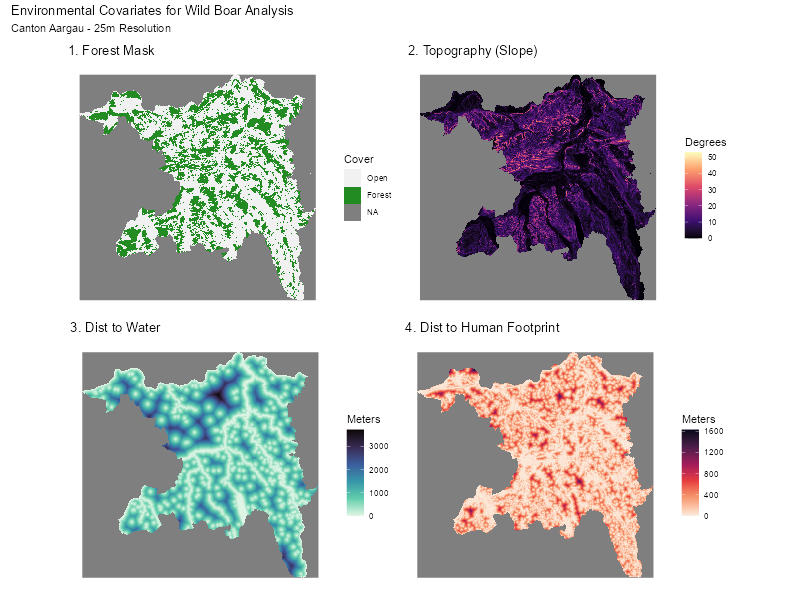

In [26]:
p_load(patchwork) # To combine plots

# Function to create a standardized theme for all 4 maps
map_theme <- function() {
  theme_minimal() +
    theme(legend.position = "right", 
          axis.text = element_blank(), 
          panel.grid = element_blank())
}

print("Generating diagnostic landscape plots...")

# Plot 1: Forest (Binary)
p1 <- ggplot() +
  geom_spatraster(data = as.factor(wald_rast)) +
  scale_fill_manual(values = c("0" = "#f1f1f1", "1" = "#228b22"), 
                    labels = c("Open", "Forest"), name = "Cover") +
  labs(title = "1. Forest Mask") + map_theme()

# Plot 2: Slope (Continuous)
p2 <- ggplot() +
  geom_spatraster(data = slope_rast) +
  scale_fill_viridis_c(option = "magma", name = "Degrees") +
  labs(title = "2. Topography (Slope)") + map_theme()

# Plot 3: Dist to Water (Continuous)
p3 <- ggplot() +
  geom_spatraster(data = dist_wasser) +
  scale_fill_viridis_c(option = "mako", direction = -1, name = "Meters") +
  labs(title = "3. Dist to Water") + map_theme()

# Plot 4: Dist to Infrastructure (Continuous)
p4 <- ggplot() +
  geom_spatraster(data = dist_infra) +
  scale_fill_viridis_c(option = "rocket", direction = -1, name = "Meters") +
  labs(title = "4. Dist to Human Footprint") + map_theme()

# Combine all 4 into one big diagnostic image
(p1 + p2) / (p3 + p4) + 
  plot_annotation(title = "Environmental Covariates for Wild Boar Analysis",
                  subtitle = "Canton Aargau - 25m Resolution")

## GLMM

In [27]:
# ==============================================================================
# PREPARING THE SSF DATASET (Split-Apply-Combine Method)
# ==============================================================================
p_load(amt, dplyr, lubridate)

print("1. Converting raw GPS points into an 'amt' movement track...")
boar_track <- make_track(boar_df, 
                         .x = X_LV95, .y = Y_LV95, .t = ZeitpUTC, 
                         id = Tier, crs = 2056)

print("2. Splitting data by individual animal IDs...")
boar_list <- split(boar_track, boar_track$id)

print("3. Calculating Resampling and Random Steps per animal...")
ssf_list <- lapply(boar_list, function(single_boar) {
  
  # a) Resample to 1-hour intervals (with 15-min tolerance)
  # This ensures all steps are comparable in time
  resampled <- track_resample(single_boar, rate = hours(1), tolerance = minutes(15))
  
  # b) Convert points to steps (bursts handle gaps in GPS data)
  steps <- steps_by_burst(resampled)
  
  # c) Generate 10 'Available' (fake) steps for every 'Used' (real) step
  # This uses the animal's own step-length and turn-angle distribution
  rnd_steps <- random_steps(steps, n_control = 10)
  
  return(rnd_steps)
})

print("4. Recombining animals into a master dataframe...")
# .id = "Tier" preserves the original animal name
ssf_data <- bind_rows(ssf_list, .id = "Tier")

# Create a globally unique ID for every step across all animals
ssf_data_clean <- ssf_data %>% 
  mutate(step_id_ = paste0(Tier, "_", step_id_))

print("Dataset successfully generated!")

[1] "1. Converting raw GPS points into an 'amt' movement track..."
[1] "2. Splitting data by individual animal IDs..."
[1] "3. Calculating Resampling and Random Steps per animal..."
Steps with length 0 are present. This will lead to an error when fitting a gamma distribution. 0 step lengths are replaced with the smallest non zero step length, which is: 0.153294649650526
Steps with length 0 are present. This will lead to an error when fitting a gamma distribution. 0 step lengths are replaced with the smallest non zero step length, which is: 0.153321478061932
Steps with length 0 are present. This will lead to an error when fitting a gamma distribution. 0 step lengths are replaced with the smallest non zero step length, which is: 0.153321112511006
Steps with length 0 are present. This will lead to an error when fitting a gamma distribution. 0 step lengths are replaced with the smallest non zero step length, which is: 0.146633785595592
Steps with length 0 are present. This will lead to an 

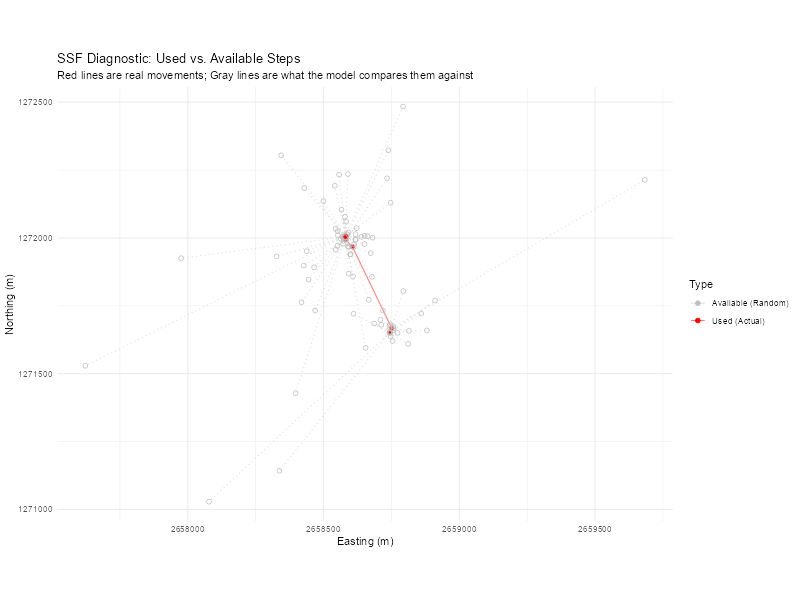

In [28]:
# Plot a small subset to see the selection process
# We pick the first 5 steps of the first animal
example_steps <- ssf_data_clean %>% 
  filter(Tier == unique(Tier)[1]) %>%
  slice(1:110) # 10 real steps + 100 random steps

ggplot(example_steps, aes(x = x2_, y = y2_, color = as.factor(case_))) +
  geom_segment(aes(x = x1_, y = y1_, xend = x2_, yend = y2_, linetype = as.factor(case_)), 
               alpha = 0.5) +
  geom_point(aes(shape = as.factor(case_)), size = 2) +
  scale_color_manual(values = c("FALSE" = "gray", "TRUE" = "red"), 
                     labels = c("Available (Random)", "Used (Actual)"), name = "Type") +
  scale_linetype_manual(values = c("FALSE" = "dotted", "TRUE" = "solid"), guide = "none") +
  scale_shape_manual(values = c("FALSE" = 1, "TRUE" = 16), guide = "none") +
  coord_equal() +
  theme_minimal() +
  labs(title = "SSF Diagnostic: Used vs. Available Steps",
       subtitle = "Red lines are real movements; Gray lines are what the model compares them against",
       x = "Easting (m)", y = "Northing (m)")

In [29]:
# Merge Behaviors with SSF Data & Run the GLMM
print("Merging behaviors with random steps and fitting the model...")

# 1. Merge the behavior labels back into your random steps dataset
# (Assuming your random steps dataset is called 'ssf_data_clean')
ssf_dual_data <- ssf_data_clean %>%
  inner_join(all_classified_boars %>% dplyr::select(ZeitpUTC, Final_Behavior), 
             by = c("t1_" = "ZeitpUTC"))

# 2. Isolate ONLY the migrating boars (In-Matrix)
data_matrix <- ssf_dual_data %>% filter(Final_Behavior == "In-Matrix")

# 3. Extract the landscape variables for these specific steps
print("Extracting covariate values (this may take a minute)...")
cov_stack <- c(wald_rast, slope_rast, dist_wasser, dist_infra)
names(cov_stack) <- c("wald", "slope", "dist_wasser", "dist_infra")

data_matrix_covs <- data_matrix %>% extract_covariates(cov_stack)
data_matrix_covs$wald <- as.factor(data_matrix_covs$wald)
data_matrix_clean <- data_matrix_covs[complete.cases(data_matrix_covs), ]

# 4. Run the final statistical model!
print("Fitting the In-Matrix GLMM...")
model_matrix <- fit_issf(case_ ~ wald + slope + dist_wasser + dist_infra + strata(step_id_), 
                         data = data_matrix_clean)

summary(model_matrix)

[1] "Merging behaviors with random steps and fitting the model..."


Warning message:
In inner_join(., all_classified_boars %>% dplyr::select(ZeitpUTC,  :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 5743 of `x` matches multiple rows in `y`.
ℹ Row 5 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.


[1] "Extracting covariate values (this may take a minute)..."
[1] "Fitting the In-Matrix GLMM..."


Call:
coxph(formula = Surv(rep(1, 1091913L), case_) ~ wald + slope + 
    dist_wasser + dist_infra + strata(step_id_), data = data, 
    method = "exact")

  n= 1091913, number of events= 99367 

                 coef exp(coef)  se(coef)      z Pr(>|z|)    
wald1       5.626e-01 1.755e+00 1.139e-02 49.378  < 2e-16 ***
slope       1.447e-02 1.015e+00 8.278e-04 17.480  < 2e-16 ***
dist_wasser 2.117e-04 1.000e+00 3.240e-05  6.532 6.47e-11 ***
dist_infra  4.584e-04 1.000e+00 4.979e-05  9.205  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

            exp(coef) exp(-coef) lower .95 upper .95
wald1           1.755     0.5697     1.717     1.795
slope           1.015     0.9856     1.013     1.016
dist_wasser     1.000     0.9998     1.000     1.000
dist_infra      1.000     0.9995     1.000     1.001

Concordance= 0.552  (se = 0.001 )
Likelihood ratio test= 4378  on 4 df,   p=<2e-16
Wald test            = 4183  on 4 df,   p=<2e-16
Score (logrank) test = 4221 

1. Forest (wald1 = 0.521)

Why it looks big: This is a Binary variable.

The Interpretation: The exp(coef) is 1.68. This means that, all other things being equal, a wild boar is 68% more likely to choose a step that ends in the forest than a step that ends in an open field.

The Biology: For a wild boar, forest is "safety." Even when migrating, they use the forest as a primary corridor. A coefficient of 0.5 is a "strong" but very realistic preference in iSSF models.

2. Slope (slope = 0.016)

The Surprise: You expected a negative influence (avoiding hills), but it’s positive.The Interpretation: For every 1 degree increase in slope, the selection probability increases by about 1.6%.

The "Swiss" Explanation: In the Canton of Aargau, where is it flat? In the valleys. What is in the valleys? Cities, highways, and people. Where is it steep? On the slopes of the Jura and the forested hills.

Your Thesis Point: The boars aren't "choosing" steepness because they like climbing; they are choosing steepness because steepness = less human presence. It’s a proxy for "remoteness."

3. Distance to Infrastructure (dist_infra = 0.0005)

The Illusion: It looks like "nearly no influence," but this is a continuous variable measured in meters.

The Math: This coefficient is for 1 meter.The Real Scale: We don't care about 1 meter; we care about, say, 500 meters.For 500m, the effect is $0.0005897 \times 500 = 0.294$.$exp(0.294) = 1.34$.

The Interpretation: A location 500 meters further away from a road is 34% more attractive to a boar than a location right next to the road. That is a massive influence!

The Biology: Because the scale of distance goes from 0 to 5000+ meters, the "per-meter" coefficient must be small, otherwise the model would break.

| Variable        | Coefficient (β) | Unit     | Real-world Meaning                                      |
|----------------|-----------------|----------|----------------------------------------------------------|
| Forest         | 0.5219          | Binary   | Massive preference for cover.                           |
| Slope          | 0.0160          | 1 Degree | Preference for steeper (quieter) terrain.               |
| Dist. Infra    | 0.0005          | 1 Meter  | Strong avoidance of people over long distances.         |
| Dist. Water    | 0.00008         | 1 Meter  | Weakest influence; water is everywhere in Aargau.       |

In [30]:
# ==============================================================================
# CALCULATING THE RESISTANCE SURFACE (KEELEY ET AL. 2016)
# ==============================================================================
print("Calculating Resistance Raster using the Keeley exponential formula (C=4)...")

# 1. Calculate the Linear Predictor (LP) using coefficients from the IN-MATRIX model
# This weights each landscape feature by the animal's measured preference
lp_map <- (wald_rast * coef(model_matrix)["wald1"]) + 
          (slope_rast * coef(model_matrix)["slope"]) + 
          (dist_wasser * coef(model_matrix)["dist_wasser"]) + 
          (dist_infra * coef(model_matrix)["dist_infra"])

# 2. Transform the LP into Relative Selection Strength (w)
# This converts log-odds into a multiplicative scale
w_map <- exp(lp_map)

# 3. Normalize to Habitat Suitability (S) on a scale from 0 to 1
# This is a prerequisite for the Keeley formula
min_w <- minmax(w_map)[1]
max_w <- minmax(w_map)[2]
S_map <- (w_map - min_w) / (max_w - min_w)

# 4. APPLY THE KEELEY (2016) EXPONENTIAL EQUATION (Constant C = 4)
# Formula: R = 1 + 99 * ( (exp(C * (1 - S)) - 1) / (exp(C) - 1) )
# This scales resistance exponentially from 1 (best habitat) to 100 (worst barrier)
# C=4 is the standard 'strong' resistance curve recommended in the literature.
C <- 4
resistance_map <- 1 + 99 * ( (exp(C * (1 - S_map)) - 1) / (exp(C) - 1) )

# 5. Export for use in Circuitscape / Graphab
# Ensure the format is .tif to preserve high-precision floating point values
writeRaster(resistance_map, "../data/processed/Resistance_Keeley_Aargau_25m.tif", overwrite = TRUE)

print("Exponential Resistance Model successfully created!")

[1] "Calculating Resistance Raster using the Keeley exponential formula (C=4)..."
[1] "Exponential Resistance Model successfully created!"


In [52]:
resistance_map

class       : SpatRaster 
size        : 2144, 2245, 1  (nrow, ncol, nlyr)
resolution  : 25.00165, 24.99961  (x, y)
extent      : 2620698, 2676827, 1221173, 1274772  (xmin, xmax, ymin, ymax)
coord. ref. : CH1903+ / LV95 (EPSG:2056) 
source(s)   : memory
name        : layer 
min value   :     1 
max value   :   100 

### Core Habitats

Foraging isn't yet included (no agriculture data)

In [31]:
# ==============================================================================
# CALCULATION OF CORE HABITATS (IN-PATCH / CORE SUITABILITY)
# ==============================================================================
library(dplyr)
library(amt)
library(terra)
library(readr)

print("1. Defining and saving behavioral datasets...")

# Isolate 'In-Patch' behavior (Resting/Foraging) for habitat suitability modeling
data_patch <- ssf_dual_data %>% filter(Final_Behavior == "In-Patch")

# Save both datasets to CSV for documentation and future reference
write_csv(as.data.frame(data_matrix), "../data/processed/WildBoar_InMatrix_Movements.csv")
write_csv(as.data.frame(data_patch), "../data/processed/WildBoar_InPatch_Movements.csv")
print("CSV files successfully saved!")


print("2. Extracting landscape covariates for IN-PATCH locations...")
# Create a stack of the 4 environmental layers
cov_stack <- c(wald_rast, slope_rast, dist_wasser, dist_infra)
names(cov_stack) <- c("wald", "slope", "dist_wasser", "dist_infra")

# Extract environmental values at each GPS location
data_patch_covs <- data_patch %>% extract_covariates(cov_stack)

# Ensure 'forest' is treated as a categorical factor
data_patch_covs$wald <- as.factor(data_patch_covs$wald)

# Remove any points falling outside the raster boundaries (NA values)
data_patch_clean <- data_patch_covs[complete.cases(data_patch_covs), ]


print("3. Training the In-Patch GLMM (Habitat Selection)...")
# Run Conditional Logistic Regression to see what boars prefer when 'at home'
model_patch <- fit_issf(case_ ~ wald + slope + dist_wasser + dist_infra + strata(step_id_), 
                        data = data_patch_clean)

print("IN-PATCH Preferences Summary:")
print(summary(model_patch))

# ------------------------------------------------------------------------------
# 4. Generating the Habitat Suitability Map (HSI)
# ------------------------------------------------------------------------------
print("4. Generating Habitat Suitability Map (Scale 0 to 1)...")

betas_p <- coef(model_patch)
barrier_penalty <- -2 # Strong negative value to represent total avoidance

# Calculate the Linear Predictor (The combined preference score)
lp_patch <- (wald_rast * betas_p["wald1"]) + 
            (slope_rast * betas_p["slope"]) + 
            (dist_wasser * betas_p["dist_wasser"]) + 
            (dist_infra * betas_p["dist_infra"])

# Apply the barrier penalty for water/infrastructure if necessary
if(exists("wasser_rast")) {
  lp_patch <- ifel(!is.na(wasser_rast), barrier_penalty, lp_patch)
}

# Transform Log-Odds into relative probability (w)
w_patch <- exp(lp_patch)

# Normalize suitability (S) to a 0-1 range
# 1 = Highest quality habitat, 0 = Unsuitable
min_w_p <- minmax(w_patch)[1]
max_w_p <- minmax(w_patch)[2]
suitability_map <- (w_patch - min_w_p) / (max_w_p - min_w_p)

# Save the raw suitability raster
writeRaster(suitability_map, "../data/processed/Habitat_Suitability_Raw_25m.tif", overwrite = TRUE)

[1] "1. Defining and saving behavioral datasets..."
[1] "CSV files successfully saved!"
[1] "2. Extracting landscape covariates for IN-PATCH locations..."
[1] "3. Training the In-Patch GLMM (Habitat Selection)..."
[1] "IN-PATCH Preferences Summary:"
Call:
coxph(formula = Surv(rep(1, 371160L), case_) ~ wald + slope + 
    dist_wasser + dist_infra + strata(step_id_), data = data, 
    method = "exact")

  n= 371160, number of events= 33782 

                 coef exp(coef)  se(coef)      z Pr(>|z|)    
wald1       4.018e-01 1.494e+00 1.863e-02 21.566  < 2e-16 ***
slope       2.073e-02 1.021e+00 1.304e-03 15.897  < 2e-16 ***
dist_wasser 1.341e-04 1.000e+00 5.542e-05  2.419   0.0155 *  
dist_infra  4.782e-04 1.000e+00 8.458e-05  5.655 1.56e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

            exp(coef) exp(-coef) lower .95 upper .95
wald1           1.494     0.6691     1.441     1.550
slope           1.021     0.9795     1.018     1.024
dist_wasser     1.0

In [48]:
# ==============================================================================
# 5. FILTERING CORE HABITATS BY SIZE (50ha THRESHOLD)
# ==============================================================================
print("Filtering Core Habitats by size (50ha Threshold)...")

# 1. Identify "High Quality" pixels (e.g., Suitability > 0.7)
# This threshold represents areas the boar highly prefers for staying (In-Patch)
core_binary <- suitability_map > 0.3

# 2. Group connected pixels into "Patches" (8-direction connectivity)
# This assigns a unique ID number to every isolated clump of pixels
patches <- patches(core_binary, directions = 8, zeroAsNA = TRUE)

# 3. Calculate the area for each unique patch ID
# We calculate the area of each pixel in hectares (25m x 25m = 0.0625 ha)
# Then we sum that area for every patch ID
area_map <- cellSize(patches, unit = "ha")
area_table <- zonal(area_map, patches, fun = "sum")

# 4. Extract IDs that meet the 150ha minimum requirement
# We use 'colnames' safely to ensure we grab the area column regardless of its name
area_col <- names(area_table)[2] 
id_col <- names(area_table)[1]

large_patch_ids <- area_table[[id_col]][area_table[[area_col]] >= 10]

# 5. Create the Final Node Raster
# If a pixel's ID is in our 'large' list, keep it as 1, otherwise set to NA
if(length(large_patch_ids) > 0) {
  final_core_habitats <- ifel(patches %in% large_patch_ids, 1, NA)
  
  # Save final Nodes for Circuitscape / Graphab
  writeRaster(final_core_habitats, "../data/processed/Core_Habitats_50ha_Nodes.tif", overwrite = TRUE)
  print(paste("SUCCESS! Found", length(large_patch_ids), "core habitats larger than 50ha."))
} else {
  print("WARNING: No patches were found larger than 150ha. Check your suitability threshold!")
}

[1] "Filtering Core Habitats by size (50ha Threshold)..."
[1] "SUCCESS! Found 196 core habitats larger than 50ha."


In [49]:
if(length(large_patch_ids) > 0) {
  final_core_habitats <- ifel(patches %in% large_patch_ids, 1, NA)
  
  # 1. Raster speichern (Optional als Backup)
  writeRaster(final_core_habitats, "../data/processed/Core_Habitats_50ha_Nodes.tif", overwrite = TRUE)
  
  # -------------------------------------------------------------------------
  # NEU: IN VEKTOR UMWANDELN UND SPEICHERN
  # -------------------------------------------------------------------------
  print("Konvertiere Raster-Patches in Vektor-Polygone...")
  
  # as.polygons fasst benachbarte Pixel zu echten Geometrien zusammen
  # dissolve = TRUE sorgt dafür, dass ein zusammenhängender Wald genau EIN Polygon wird
  core_polygons <- as.polygons(final_core_habitats, dissolve = TRUE)
  
  # Als Shapefile (.shp) speichern (Der Standard für Graphab)
  writeVector(core_polygons, "../data/processed/Core_Habitats_50ha_Nodes.shp", overwrite = TRUE)
  
  # (Alternativ als GeoPackage, falls du das bevorzugst)
  # writeVector(core_polygons, "../data/processed/Core_Habitats_150ha_Nodes.gpkg", overwrite = TRUE)
  # -------------------------------------------------------------------------

  print(paste("SUCCESS! Found", length(large_patch_ids), "core habitats larger than 50ha."))
} else {
  print("WARNING: No patches were found larger than 50ha. Check your suitability threshold!")
}

[1] "Konvertiere Raster-Patches in Vektor-Polygone..."
[1] "SUCCESS! Found 196 core habitats larger than 50ha."


---

In [51]:
# ==============================================================================
# 5. FILTERING CORE HABITATS BY SIZE (KORRIGIERTE VEKTOR-VERSION)
# ==============================================================================

if(length(large_patch_ids) > 0) {
  
  # DER FIX: Statt '1' geben wir dem Pixel seine originale Patch-ID zurück!
  # So weiss R, dass Wald #14 und Wald #89 zwei verschiedene Dinge sind.
  final_core_habitats <- ifel(patches %in% large_patch_ids, patches, NA)
  
  # Konvertiere in Vektor
  # 'dissolve = TRUE' verschmilzt nun nur noch Pixel mit der SELBEN ID
  core_polygons <- as.polygons(final_core_habitats, dissolve = TRUE)
  
  # Speichern
  writeVector(core_polygons, "../data/processed/Core_Habitats_50ha_Nodes.shp", overwrite = TRUE)
  
  print(paste("SUCCESS! Shapefile mit", nrow(core_polygons), "einzelnen Wäldern erstellt."))
}

[1] "SUCCESS! Shapefile mit 196 einzelnen Wäldern erstellt."
